# Fraud Detection - Robustness Analysis

This notebook checks whether model performance is consistent across transaction amount segments.

Focus:
- PR-AUC (Average Precision) by amount segment
- Recall stability by amount segment at the selected threshold
- Simple drift simulation on Amount distribution


# Import Libraries

In [6]:
import pandas as pd    
import numpy as np          
import joblib, json
import matplotlib.pyplot as plt              

from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score

RANDOM_STATE = 42

# Load Model & Data

In [3]:
model = joblib.load("../models/baseline_pipeline.pkl")

df = pd.read_csv("../data/processed/creditcard_processed.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,LogAmount,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.0


# Train/Test Split & Probabilities

In [9]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    train_size=0.20,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y
                                                    )

y_proba = model.predict_proba(X_test)[:, 1]

# Build Amount Segments

In [11]:

seg = pd.DataFrame(index=X_test.index)
seg["Amount"] = df.loc[X_test.index, "Amount"]
seg["Class"] = y_test.values 
seg["Probability"] = y_proba

# Quartile bins
seg["amount_bin"] = pd.qcut(seg["Amount"],
                            q=4,
                            labels=["Low", "Medium", "High", "Very High"])

seg.head()

,Amount,Class,Probability,amount_bin
249933,4.48,0,0.000223,Low
135079,26.89,0,0.000428,High
41877,1368.15,0,0.000131,Very High
205966,193.90,0,0.000573,Very High
226539,42.98,0,0.000048,High


# Segment Count & Fraud Rate

In [14]:
segment_stats = seg.groupby("amount_bin").agg(n=("Class", "size"),
                                              n_fraud=("Class", "sum"))

segment_stats["fraud_rate"] = segment_stats["n_fraud"] / segment_stats["n"]

segment_stats.head()

C:\Users\abdal\AppData\Local\Temp\ipykernel_66784\1861046899.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_stats = seg.groupby("amount_bin").agg(n=("Class", "size"),


,n,n_fraud,fraud_rate
amount_bin,,,
Low,56761,170,0.002995
Medium,56734,40,0.000705
High,56742,37,0.000652
Very High,56744,131,0.002309


# PR-AUC by Segment

In [16]:
pr_auc_by_segment = {}

for segment in seg["amount_bin"].cat.categories:
    subset = seg[seg["amount_bin"] == segment]
    
    if subset["Class"].sum() == 0:
        pr_auc_by_segment[str(segment)] == np.nan
    else:
        pr_auc_by_segment[str(segment)] = average_precision_score(subset["Class"], subset["Probability"])

pr_auc_by_segment

{'Low': 0.8133367346051096,
 'Medium': 0.7814162842575377,
 'High': 0.8782541878509256,
 'Very High': 0.6610522058076477}

## Segment Performance Interpretation

- PR-AUC (Average Precision) reflects ranking quality under class imbalance.
- Large PR-AUC differences across amount segments can indicate inconsistent model behavior.
- Segments with very few fraud cases can produce unstable PR-AUC always check `n_fraud` per segment.


# Load Threshold & Recall by Segment

In [21]:
with open("../models/metadata.json", "r") as f:
    metadata = json.load(f)

threshold = float(metadata["threshold"])
seg["pred"] = (seg["Probability"] >= threshold).astype(int)

recall_by_segment = {}

for segment in seg["amount_bin"].cat.categories:
    subset = seg[seg["amount_bin"] == segment]
    n_pos = int(subset["Class"].sum())
    if n_pos == 0:
        recall_by_segment[str(segment)] = np.nan
        continue
    tp = ((subset["pred"] == 1) & (subset["Class"] == 1)).sum()
    fn = ((subset["pred"] == 0) & (subset["Class"] == 1)).sum()
    recall_by_segment[str(segment)] = float(tp / (tp + fn))

recall_by_segment

{'Low': 0.7176470588235294,
 'Medium': 0.65,
 'High': 0.7567567567567568,
 'Very High': 0.7557251908396947}

## Recall Stability Reflection

- Recall consistency across segments is important because missed fraud varies in cost.
- If recall drops in high-value segments, the model may fail where risk is highest.
- Interpret recall alongside `n_fraud` very small fraud counts make segment recall noisy.


# Drift Simulation & PSI

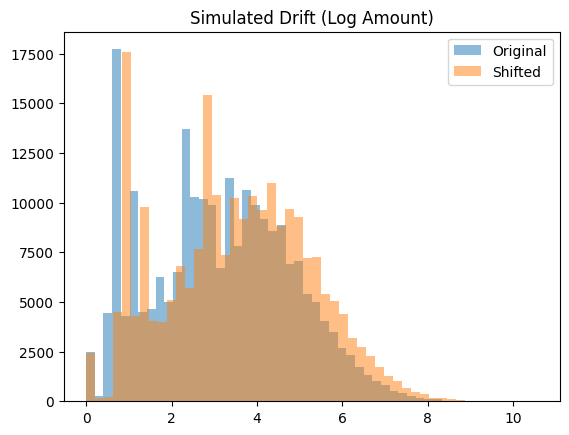

PSI Value: 0.15852543697454763


In [23]:
def psi(expected, actual, bins=10, eps=1e-6):
    # expected, actual: arrays
    quantiles = np.quantile(expected, np.linspace(0, 1, bins + 1))
    quantiles[0], quantiles[-1] = -np.inf, np.inf

    e_counts = np.histogram(expected, bins=quantiles)[0]
    a_counts = np.histogram(actual, bins=quantiles)[0]

    e_perc = e_counts / max(e_counts.sum(), 1)
    a_perc = a_counts / max(a_counts.sum(), 1)

    e_perc = np.clip(e_perc, eps, 1)
    a_perc = np.clip(a_perc, eps, 1)

    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))

original = seg["Amount"].values
shifted = original * 1.5

plt.hist(np.log1p(original), bins=50, alpha=0.5, label="Original")
plt.hist(np.log1p(shifted), bins=50, alpha=0.5, label="Shifted")
plt.legend()
plt.title("Simulated Drift (Log Amount)")
plt.show()

psi_value = psi(original, shifted, bins=10)
print(f"PSI Value: {psi_value}")

## Drift Insight

The simulated shift increases transaction amounts. Monitoring input drift (e.g., PSI on `Amount`) helps detect distribution changes early.
Typical PSI interpretation (rule of thumb):
- `< 0.1`: small/no drift
- `0.1–0.25`: moderate drift
- `> 0.25`: large drift